# Objetivo 2

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from lightgbm import early_stopping, log_evaluation
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_recall_curve

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [2]:
bolivia_train = pd.read_csv('../data/bolivia_train_cleaned.csv')
brasil_train = pd.read_csv('../data/brasil_train_cleaned.csv')
guate_train = pd.read_csv('../data/guatemala_train_cleaned.csv')
bolivia_test = pd.read_csv('../data/bolivia_test_cleaned.csv')
brasil_test = pd.read_csv('../data/brasil_test_cleaned.csv')
guate_test = pd.read_csv('../data/guatemala_test_cleaned.csv')

In [3]:
N_TRIALS    = 50
MIN_RECALL  = 0.90
WEIGHT_BOL  = 0.8
WEIGHT_BRA  = 1.2

In [4]:
def calculate_fp_ratio(y_true, y_pred):
    return 1 - precision_score(y_true, y_pred, zero_division=0)

In [5]:
dfs = [bolivia_train, bolivia_test, brasil_train, brasil_test]
def print_desbalance(df):
    print(df['is_fraud'].value_counts())

for df in dfs:
    print_desbalance(df)

is_fraud
0    79645
1     4191
Name: count, dtype: int64
is_fraud
0    15439
1      728
Name: count, dtype: int64
is_fraud
0    81262
1     2680
Name: count, dtype: int64
is_fraud
0    15533
1      525
Name: count, dtype: int64


In [6]:
"""
Federated Fraud Detection - LightGBM con 3 Metodologías
=========================================================
Bolivia + Brasil → predicción sobre Guatemala (30% = 3 tercios × 10%)

Metodologías:
  Tercio 1 → Modelo 1: FedAvg simulado (promediar pesos de modelos por banco)
  Tercio 2 → Modelo 2: Federated con domain-agnostic features + SMOTE
  Tercio 3 → Modelo 3: Stacking federado (meta-modelo sobre predicciones de ambos bancos)

Desbalance: ~19:1 → se manejan con scale_pos_weight / SMOTE / threshold tuning
"""

bolivia_fe = pd.concat([bolivia_train, bolivia_test], ignore_index=True)
brasil_fe  = pd.concat([brasil_train,  brasil_test],  ignore_index=True)
guate_fe   = pd.concat([guate_test,   guate_train],   ignore_index=True)

print(f"Bolivia total: {len(bolivia_fe):,}  fraudes: {bolivia_fe['is_fraud'].sum():,}")
print(f"Brasil  total: {len(brasil_fe):,}  fraudes: {brasil_fe['is_fraud'].sum():,}")
print(f"Guatemala total (inferencia): {len(guate_fe):,}")

EXCLUDE_COLS = {'is_fraud', 'transaction_id', 'mcc_fraud_rate', 'amount_usd'}
 
def get_feature_cols(df, exclude=EXCLUDE_COLS):
    return [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]
 
COMMON_FEATURES = sorted(
    set(get_feature_cols(bolivia_fe)) &
    set(get_feature_cols(brasil_fe)) &
    set(get_feature_cols(guate_fe)))


n_guate = len(guate_fe)
t1 = n_guate // 3

guate_t1 = guate_fe.iloc[:t1].copy()            





Bolivia total: 100,003  fraudes: 4,919
Brasil  total: 100,000  fraudes: 3,205
Guatemala total (inferencia): 100,000


In [7]:
def get_spw(y):
    neg = (y == 0).sum()
    pos = (y == 1).sum()
    return neg / pos

In [8]:
X_bra_inicial = brasil_fe[COMMON_FEATURES].fillna(0)
y_bra_inicial = brasil_fe["is_fraud"]


X_bol_inicial = bolivia_fe[COMMON_FEATURES].fillna(0)
y_bol_inicial = bolivia_fe["is_fraud"]

In [9]:
combined = pd.concat(
    [bolivia_fe, brasil_fe],
    ignore_index=True
)

In [10]:
X_global_inicial = combined[COMMON_FEATURES].fillna(0)
y_global_inicial = combined["is_fraud"]

In [11]:
X_bol, X_bol_val, y_bol, y_bol_val = train_test_split(
    X_bol_inicial,
    y_bol_inicial,
    test_size=0.20,
    stratify=y_bol_inicial,
    random_state=42
)

In [12]:
X_bra, X_bra_val, y_bra, y_bra_val = train_test_split(
    X_bra_inicial,
    y_bra_inicial,
    test_size=0.20,
    stratify=y_bra_inicial,
    random_state=42
)

In [13]:
X_global, X_global_val, y_global, y_global_val = train_test_split(
    X_global_inicial,
    y_global_inicial,
    test_size=0.20,
    stratify=y_global_inicial,
    random_state=42
)

In [14]:
spw_bol = get_spw(bolivia_fe.is_fraud)
spw_bra = get_spw(brasil_fe.is_fraud)

combined_tmp = pd.concat(
    [bolivia_fe, brasil_fe]
)

spw_global = get_spw(
    combined_tmp.is_fraud
)

print(spw_bol)
print(spw_bra)
print(spw_global)

19.329945110794878
30.201248049921997
23.61878385032004


In [15]:
sample_weights_robust = np.concatenate([
    np.full(len(X_bol), WEIGHT_BOL),  # todas las filas de Bolivia → 0.8
    np.full(len(X_bra), WEIGHT_BRA),  # todas las filas de Brasil  → 1.2
])

In [16]:
w_bol = len(bolivia_fe) / (len(bolivia_fe)+len(brasil_fe))
w_bra = len(brasil_fe) / (len(bolivia_fe)+len(brasil_fe))

## Modelo estándar 

Aquí, buscamos hacer un modelo estándar sin tener en cuenta objetivos de negocio

In [17]:
def find_best_threshold(y_true, y_prob, min_recall=MIN_RECALL):
    thresholds = np.linspace(0.01, 0.99, 200)
    best_thresh, best_fpr = 0.50, 1.0
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        rec = recall_score(y_true, y_pred, zero_division=0)
        fpr = calculate_fp_ratio(y_true, y_pred)
        if rec >= min_recall and fpr < best_fpr:
            best_fpr   = fpr
            best_thresh = t
    print(f"  → Best threshold: {best_thresh:.3f} | FP-Ratio: {best_fpr:.4f}")
    return best_thresh

def find_threshold_f1(y_true, y_prob):
    """Threshold que maximiza F1, sin restricción de recall"""
    thresholds = np.linspace(0.01, 0.99, 200)
    best_thresh, best_f1 = 0.50, 0.0
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1   = f1
            best_thresh = t
    print(f"  → Best threshold: {best_thresh:.3f} | F1: {best_f1:.4f}")
    return best_thresh

In [18]:
# ═══════════════════════════════════════════════════════════
# CHUNK 1A — FINETUNEAR CON OBJETIVO: RECALL ≥ 0.90
# ═══════════════════════════════════════════════════════════

def build_objective_recall90(X_tr, y_tr, X_val, y_val, spw):
    def objective(trial):
        params = {
            "n_estimators":      trial.suggest_int("n_estimators", 200, 1000),
            "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            "num_leaves":        trial.suggest_int("num_leaves", 31, 255),
            "max_depth":         trial.suggest_int("max_depth", 4, 12),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            "scale_pos_weight":  spw,
            "verbosity":         -1,
            "random_state":      42,
        }
        m = lgb.LGBMClassifier(**params)
        m.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
        )
        prob   = m.predict_proba(X_val)[:, 1]

        # Buscar threshold que minimice FP-Ratio con recall >= 0.90
        best_fpr = 1.0
        for t in np.linspace(0.01, 0.99, 200):
            y_pred = (prob >= t).astype(int)
            rec    = recall_score(y_val, y_pred, zero_division=0)
            fpr    = calculate_fp_ratio(y_val, y_pred)
            if rec >= 0.90 and fpr < best_fpr:
                best_fpr = fpr

        # Si ningún threshold alcanzó recall 0.90, penalizar fuertemente
        return -best_fpr if best_fpr < 1.0 else -1.0

    return objective


def tune_and_fit_recall90(name, X_tr, y_tr, X_val, y_val, spw, sample_weight=None):
    print(f"\n{'═'*50}\nTuneando (Recall ≥ 0.90): {name}\n{'═'*50}")
    study = optuna.create_study(direction="maximize")
    study.optimize(
        build_objective_recall90(X_tr, y_tr, X_val, y_val, spw),
        n_trials=N_TRIALS,
        show_progress_bar=True
    )
    print(f"  Best score (−FP-Ratio): {study.best_value:.4f}")

    best = lgb.LGBMClassifier(
        **study.best_params,
        scale_pos_weight=spw,
        verbosity=-1,
        random_state=42
    )
    fit_kwargs = dict(
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(100)]
    )
    if sample_weight is not None:
        fit_kwargs["sample_weight"] = sample_weight

    best.fit(X_tr, y_tr, **fit_kwargs)
    return best


model_bol_r90    = tune_and_fit_recall90("Bolivia", X_bol,    y_bol,    X_bol_val,    y_bol_val,    spw_bol)
m_bra_r90        = tune_and_fit_recall90("Brasil",  X_bra,    y_bra,    X_bra_val,    y_bra_val,    spw_bra)
m_global_r90     = tune_and_fit_recall90("Global",  X_global, y_global, X_global_val, y_global_val, spw_global)
model_robust_r90 = tune_and_fit_recall90("Robust",  X_global, y_global, X_global_val, y_global_val, spw_global,
                                          sample_weight=sample_weights_robust)


══════════════════════════════════════════════════
Tuneando (Recall ≥ 0.90): Bolivia
══════════════════════════════════════════════════


Best trial: 49. Best value: -0.923223: 100%|██████████| 50/50 [01:33<00:00,  1.86s/it]


  Best score (−FP-Ratio): -0.9232
[100]	valid_0's binary_logloss: 0.294016

══════════════════════════════════════════════════
Tuneando (Recall ≥ 0.90): Brasil
══════════════════════════════════════════════════


Best trial: 35. Best value: -0.960041: 100%|██████████| 50/50 [01:41<00:00,  2.02s/it]


  Best score (−FP-Ratio): -0.9600
[100]	valid_0's binary_logloss: 0.253234

══════════════════════════════════════════════════
Tuneando (Recall ≥ 0.90): Global
══════════════════════════════════════════════════


Best trial: 3. Best value: -0.93402: 100%|██████████| 50/50 [02:27<00:00,  2.95s/it]


  Best score (−FP-Ratio): -0.9340
[100]	valid_0's binary_logloss: 0.318169

══════════════════════════════════════════════════
Tuneando (Recall ≥ 0.90): Robust
══════════════════════════════════════════════════


Best trial: 33. Best value: -0.936207: 100%|██████████| 50/50 [02:34<00:00,  3.08s/it]


  Best score (−FP-Ratio): -0.9362
[100]	valid_0's binary_logloss: 0.286394


In [19]:
# ═══════════════════════════════════════════════════════════
# CHUNK 1B — FINETUNEAR ESTÁNDAR (AUC, THRESHOLD = 0.50)
# ═══════════════════════════════════════════════════════════

def build_objective_standard(X_tr, y_tr, X_val, y_val, spw):
    def objective(trial):
        params = {
            "n_estimators":      trial.suggest_int("n_estimators", 200, 1000),
            "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            "num_leaves":        trial.suggest_int("num_leaves", 31, 255),
            "max_depth":         trial.suggest_int("max_depth", 4, 12),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            "scale_pos_weight":  spw,
            "verbosity":         -1,
            "random_state":      42,
        }
        m = lgb.LGBMClassifier(**params)
        m.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
        )
        prob = m.predict_proba(X_val)[:, 1]
        precisions, recalls, thresholds = precision_recall_curve(y_val, prob)
        f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
        best_f1 = f1_scores.max()
        
        return best_f1

    return objective


def tune_and_fit_standard(name, X_tr, y_tr, X_val, y_val, spw, sample_weight=None):
    print(f"\n{'═'*50}\nTuneando (Estándar AUC): {name}\n{'═'*50}")
    study = optuna.create_study(direction="maximize")
    study.optimize(
        build_objective_standard(X_tr, y_tr, X_val, y_val, spw),
        n_trials=N_TRIALS,
        show_progress_bar=True
    )
    print(f"  Best AUC: {study.best_value:.4f}")

    best = lgb.LGBMClassifier(
        **study.best_params,
        scale_pos_weight=spw,
        verbosity=-1,
        random_state=42
    )
    fit_kwargs = dict(
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(100)]
    )
    if sample_weight is not None:
        fit_kwargs["sample_weight"] = sample_weight

    best.fit(X_tr, y_tr, **fit_kwargs)
    return best


model_bol_std    = tune_and_fit_standard("Bolivia", X_bol,    y_bol,    X_bol_val,    y_bol_val,    spw_bol)
m_bra_std        = tune_and_fit_standard("Brasil",  X_bra,    y_bra,    X_bra_val,    y_bra_val,    spw_bra)
m_global_std     = tune_and_fit_standard("Global",  X_global, y_global, X_global_val, y_global_val, spw_global)
model_robust_std = tune_and_fit_standard("Robust",  X_global, y_global, X_global_val, y_global_val, spw_global,
                                          sample_weight=sample_weights_robust)


══════════════════════════════════════════════════
Tuneando (Estándar AUC): Bolivia
══════════════════════════════════════════════════


Best trial: 23. Best value: 0.712422: 100%|██████████| 50/50 [00:09<00:00,  5.13it/s]


  Best AUC: 0.7124
[100]	valid_0's binary_logloss: 0.261168

══════════════════════════════════════════════════
Tuneando (Estándar AUC): Brasil
══════════════════════════════════════════════════


Best trial: 18. Best value: 0.546314: 100%|██████████| 50/50 [00:12<00:00,  4.10it/s]


  Best AUC: 0.5463
[100]	valid_0's binary_logloss: 0.228505

══════════════════════════════════════════════════
Tuneando (Estándar AUC): Global
══════════════════════════════════════════════════


Best trial: 47. Best value: 0.643241: 100%|██████████| 50/50 [00:28<00:00,  1.78it/s]


  Best AUC: 0.6432
[100]	valid_0's binary_logloss: 0.266659

══════════════════════════════════════════════════
Tuneando (Estándar AUC): Robust
══════════════════════════════════════════════════


Best trial: 48. Best value: 0.641312: 100%|██████████| 50/50 [00:45<00:00,  1.11it/s]


  Best AUC: 0.6413
[100]	valid_0's binary_logloss: 0.240035


In [20]:
# ═══════════════════════════════════════════════════════════
# CHUNK 2 — PREDICCIÓN SOBRE VALIDACIÓN FEDERADA
#           Estándar vs Recall90 para todos los modelos
# ═══════════════════════════════════════════════════════════

X_fed_val = pd.concat([X_bol_val, X_bra_val], ignore_index=True)
y_fed_val = pd.concat([y_bol_val, y_bra_val], ignore_index=True)

# ── Modelos por variante ──────────────────────────────────

MODELS = {
    "std": {
        "Bolivia": model_bol_std,
        "Brasil":  m_bra_std,
        "Global":  m_global_std,
        "Robust":  model_robust_std,
        "FedAvg":  None,  # ensemble, se calcula abajo
    },
    "r90": {
        "Bolivia": model_bol_r90,
        "Brasil":  m_bra_r90,
        "Global":  m_global_r90,
        "Robust":  model_robust_r90,
        "FedAvg":  None,
    },
}



# ── Calcular probabilidades ───────────────────────────────

def get_probs(models, variant):
    p = {}
    for name, model in models.items():
        if name == "FedAvg":
            p[name] = (
                w_bol * models["Bolivia"].predict_proba(X_fed_val)[:, 1]
              + w_bra * models["Brasil"].predict_proba(X_fed_val)[:, 1]
            )
        else:
            p[name] = model.predict_proba(X_fed_val)[:, 1]
    return p

probs_std = get_probs(MODELS["std"], "std")
probs_r90 = get_probs(MODELS["r90"], "r90")

# ── Calcular métricas ─────────────────────────────────────

def compute_results(probs, use_optimal_threshold=False):
    thresholds = {}
    results    = {}
    for name, prob in probs.items():
        if use_optimal_threshold:
            t = find_best_threshold(y_fed_val, prob, min_recall=0.90)
        else:
            t = find_threshold_f1(y_fed_val, prob)
        thresholds[name] = t
        y_pred = (prob >= t).astype(int)
        results[name] = {
            "ROC-AUC":   roc_auc_score(y_fed_val, prob),
            "Recall":    recall_score(y_fed_val, y_pred, zero_division=0),
            "Precision": precision_score(y_fed_val, y_pred, zero_division=0),
            "FP-Ratio":  calculate_fp_ratio(y_fed_val, y_pred),
            "F1":        f1_score(y_fed_val, y_pred, zero_division=0),
            "Threshold": t,
        }
    return thresholds, results

print("\n" + "═"*50)
print("ESTÁNDAR — Threshold = 0.50")
print("═"*50)
thresholds_std, results_std = compute_results(probs_std, use_optimal_threshold=False)
print(pd.DataFrame(results_std).T.round(4).to_string())

print("\n" + "═"*50)
print("RECALL90 — Threshold óptimo @ Recall ≥ 0.90")
print("═"*50)
thresholds_r90, results_r90 = compute_results(probs_r90, use_optimal_threshold=True)
print(pd.DataFrame(results_r90).T.round(4).to_string())


══════════════════════════════════════════════════
ESTÁNDAR — Threshold = 0.50
══════════════════════════════════════════════════
  → Best threshold: 0.187 | F1: 0.6148
  → Best threshold: 0.108 | F1: 0.4453
  → Best threshold: 0.133 | F1: 0.6480
  → Best threshold: 0.128 | F1: 0.6464
  → Best threshold: 0.113 | F1: 0.5957
         ROC-AUC  Recall  Precision  FP-Ratio      F1  Threshold
Bolivia   0.8141  0.5108     0.7721    0.2279  0.6148     0.1873
Brasil    0.7168  0.3532     0.6023    0.3977  0.4453     0.1085
Global    0.8805  0.5692     0.7520    0.2480  0.6480     0.1331
Robust    0.8984  0.5372     0.8113    0.1887  0.6464     0.1282
FedAvg    0.8362  0.5342     0.6734    0.3266  0.5957     0.1134

══════════════════════════════════════════════════
RECALL90 — Threshold óptimo @ Recall ≥ 0.90
══════════════════════════════════════════════════
  → Best threshold: 0.059 | FP-Ratio: 0.9547
  → Best threshold: 0.035 | FP-Ratio: 0.9553
  → Best threshold: 0.049 | FP-Ratio: 0.9515
  

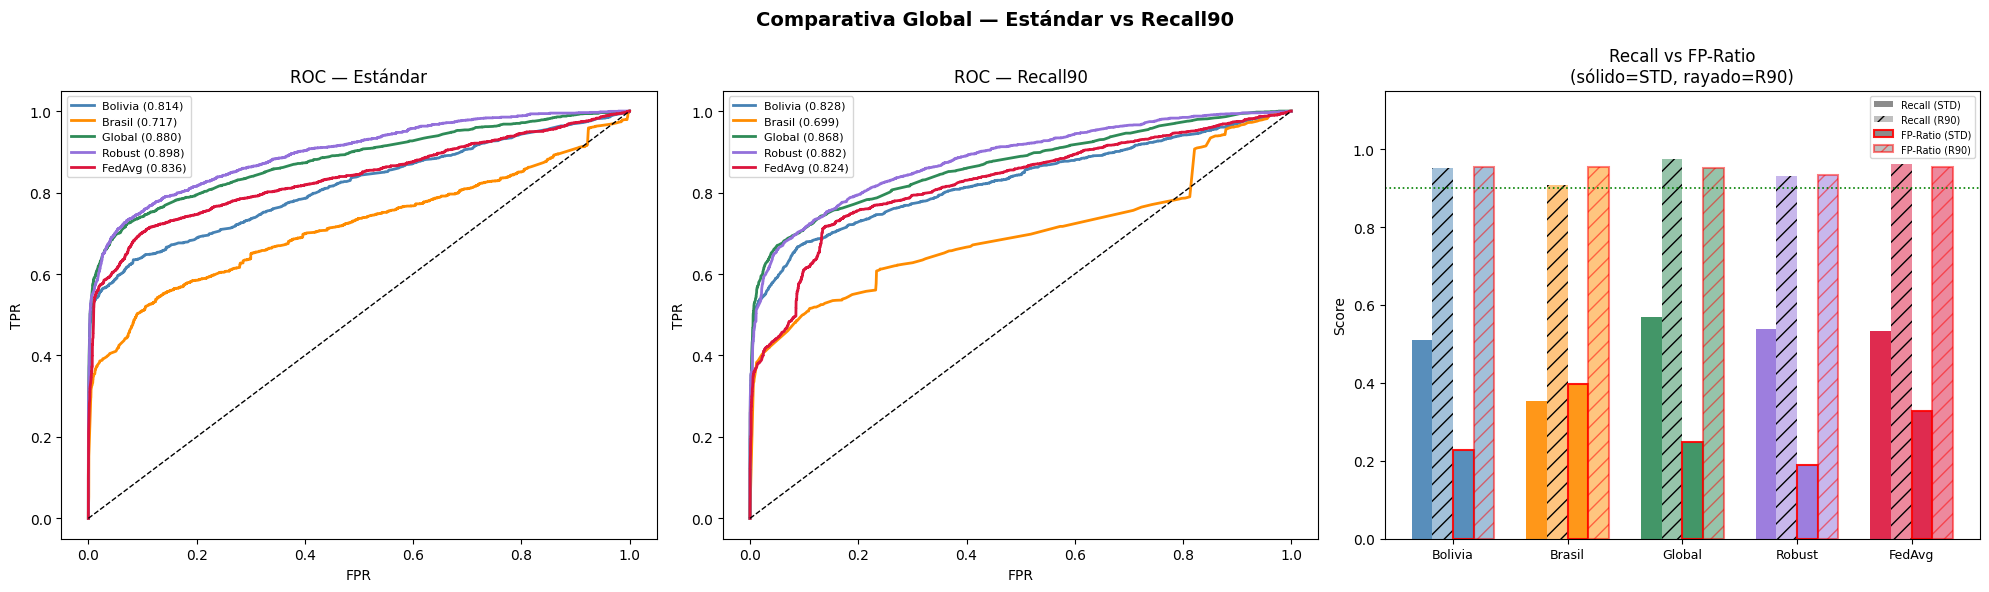

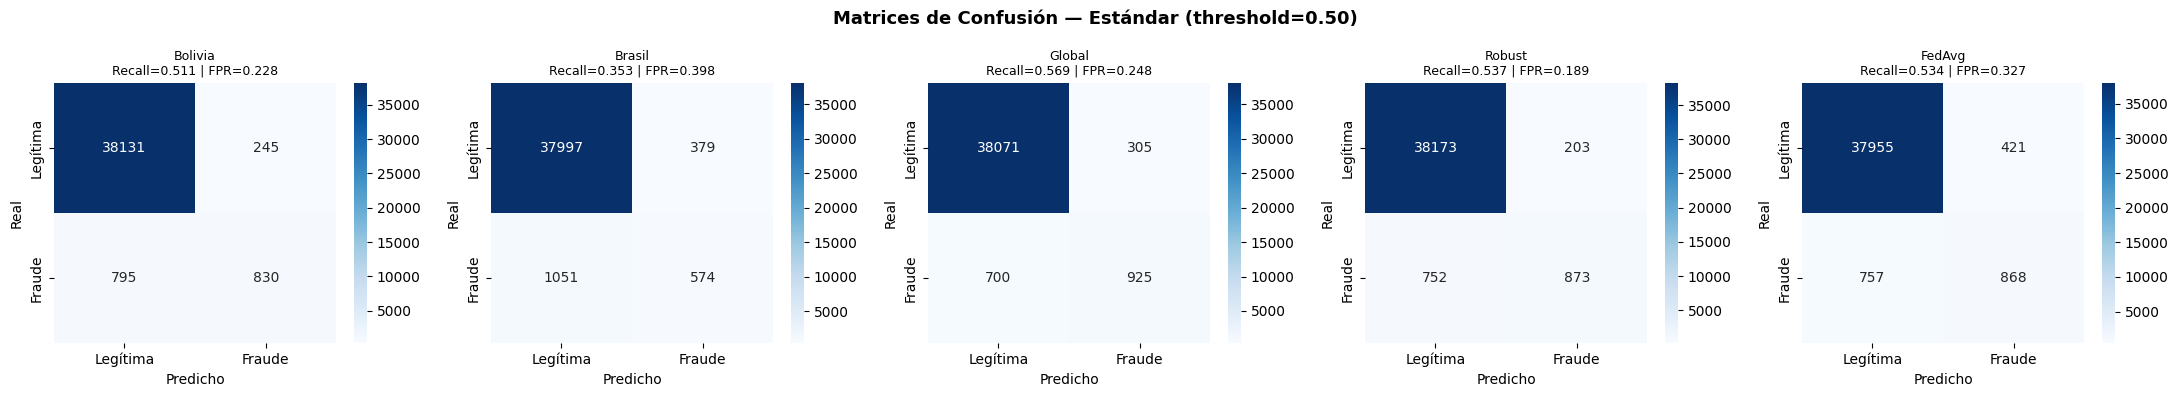

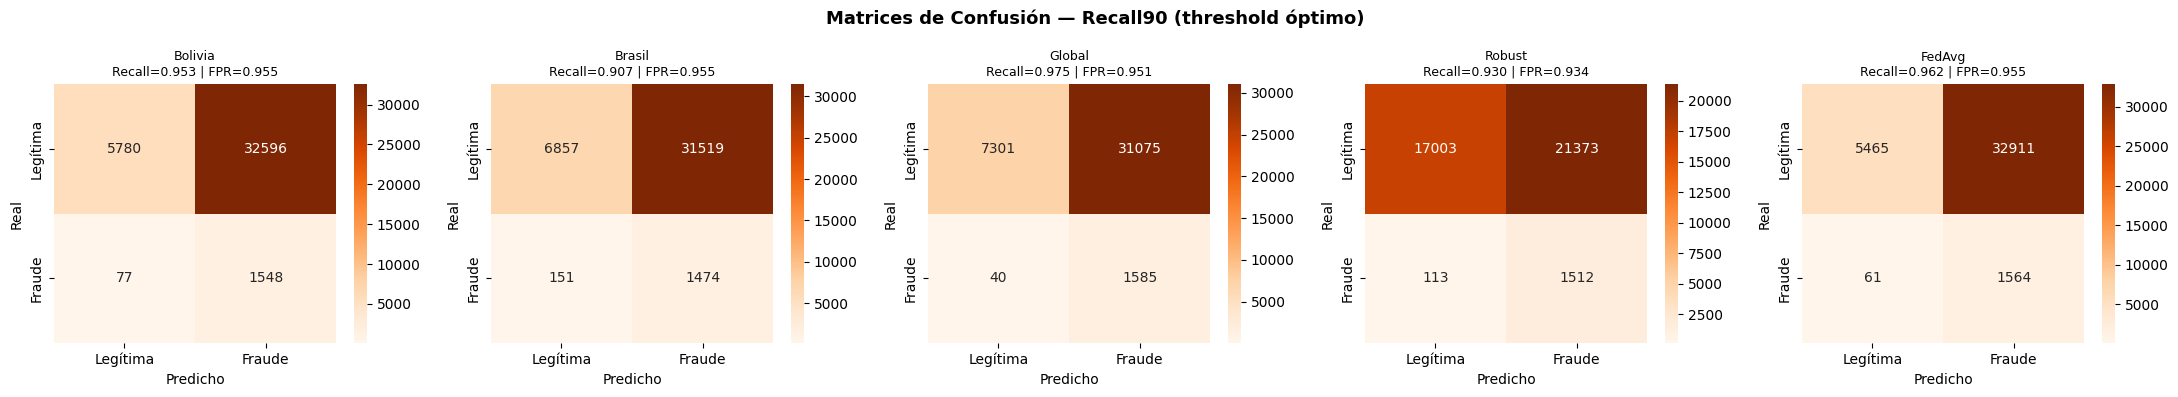

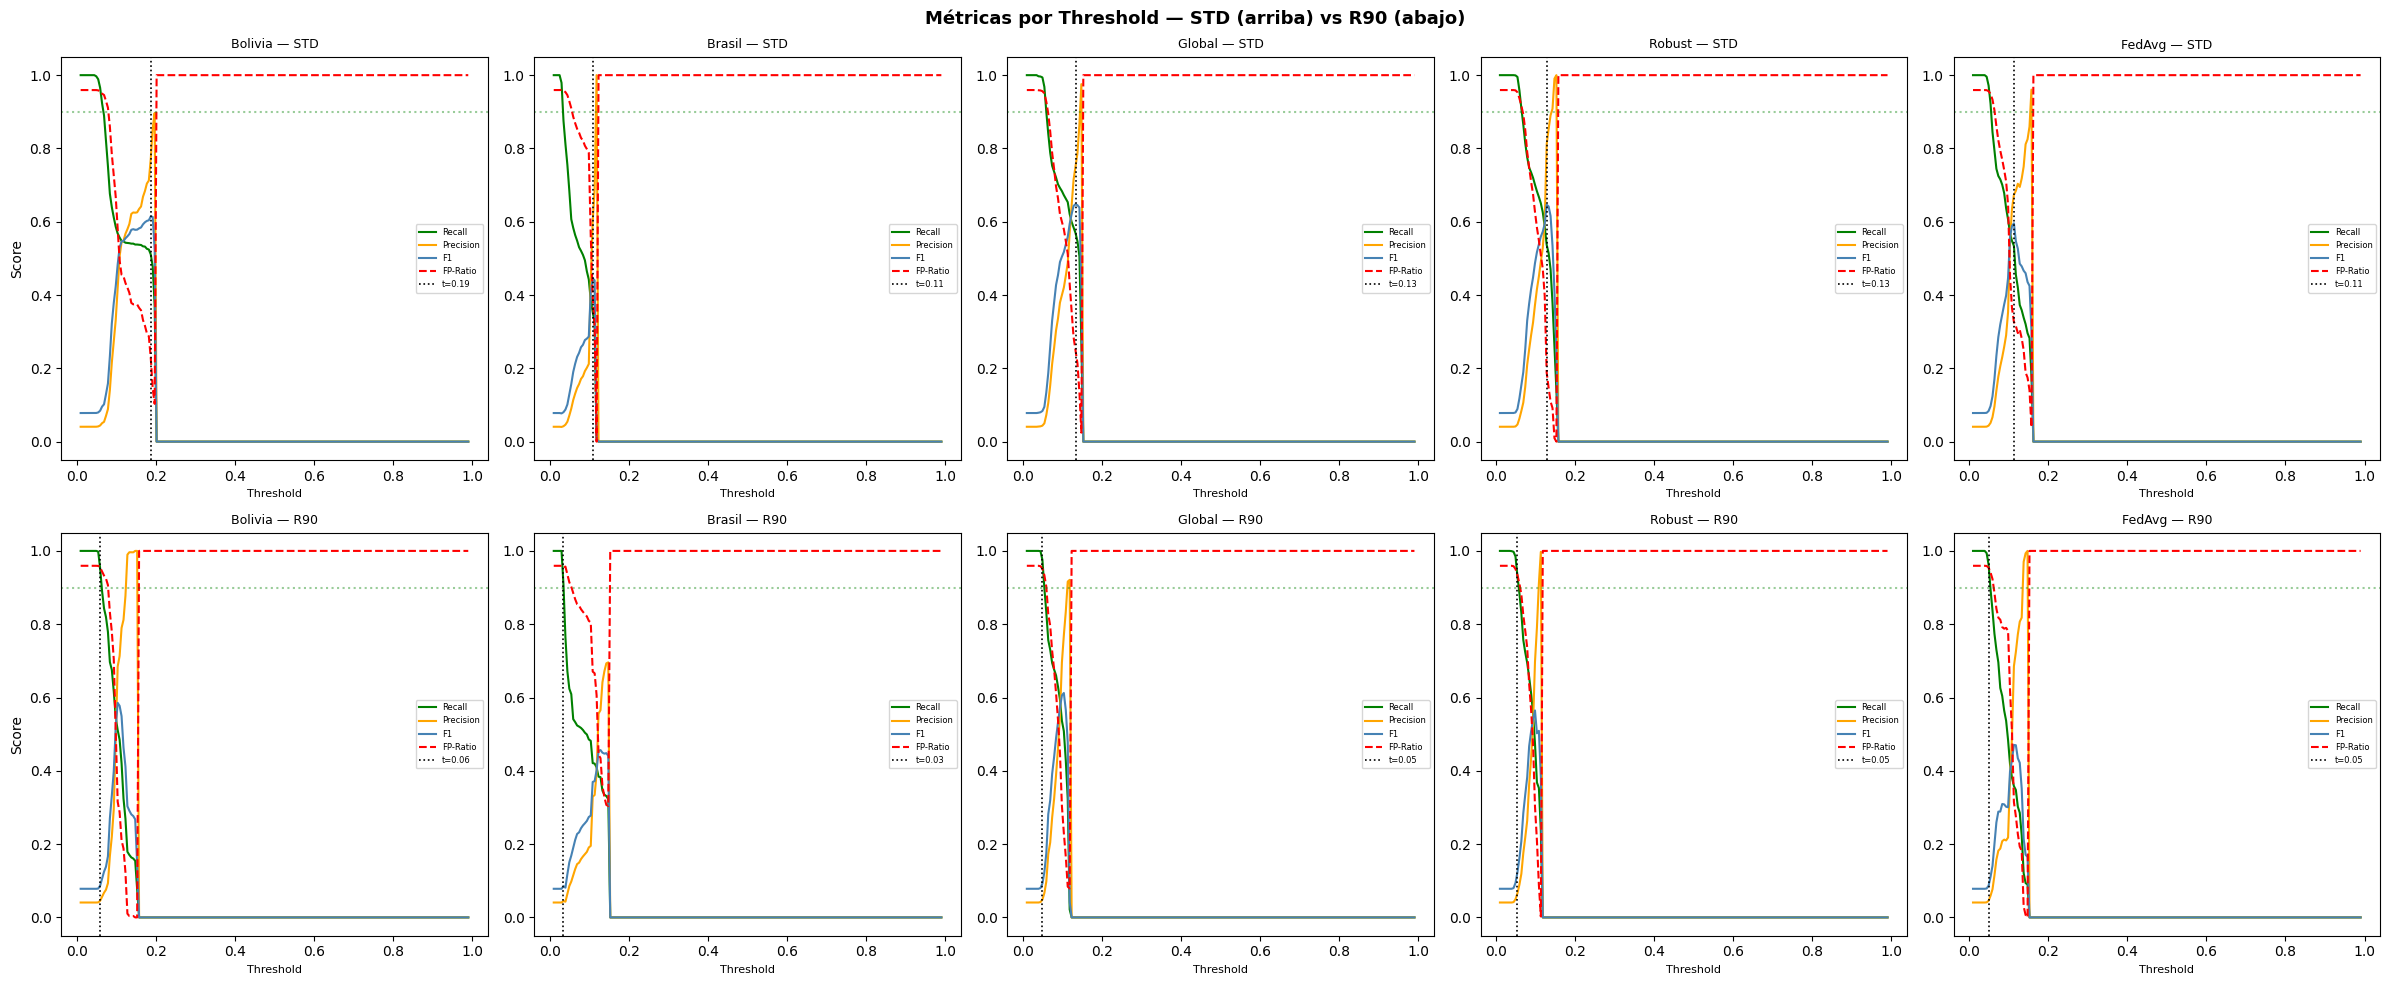

In [21]:
# ═══════════════════════════════════════════════════════════
# CHUNK 3 — GRÁFICAS COMPARATIVAS STD vs R90
# ═══════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve

MODEL_NAMES = ["Bolivia", "Brasil", "Global", "Robust", "FedAvg"]

COLORS = {
    "Bolivia": "steelblue",
    "Brasil":  "darkorange",
    "Global":  "seagreen",
    "Robust":  "mediumpurple",
    "FedAvg":  "crimson",
}

# ── Figura 1: ROC + Métricas comparativas ────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Comparativa Global — Estándar vs Recall90", fontsize=14, fontweight="bold")

# ROC — Estándar
ax = axes[0]
for name in MODEL_NAMES:
    fpr_c, tpr_c, _ = roc_curve(y_fed_val, probs_std[name])
    auc = results_std[name]["ROC-AUC"]
    ax.plot(fpr_c, tpr_c, color=COLORS[name], lw=2, label=f"{name} ({auc:.3f})")
ax.plot([0,1],[0,1], "k--", lw=1)
ax.set_title("ROC — Estándar")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.legend(fontsize=8)

# ROC — Recall90
ax = axes[1]
for name in MODEL_NAMES:
    fpr_c, tpr_c, _ = roc_curve(y_fed_val, probs_r90[name])
    auc = results_r90[name]["ROC-AUC"]
    ax.plot(fpr_c, tpr_c, color=COLORS[name], lw=2, label=f"{name} ({auc:.3f})")
ax.plot([0,1],[0,1], "k--", lw=1)
ax.set_title("ROC — Recall90")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.legend(fontsize=8)

# Bar chart: Recall y FP-Ratio lado a lado
ax = axes[2]
x         = np.arange(len(MODEL_NAMES))
bar_width  = 0.18
metrics_bar = ["Recall", "FP-Ratio"]
linestyles  = ["-", "--"]
for i, name in enumerate(MODEL_NAMES):
    recall_std = results_std[name]["Recall"]
    recall_r90 = results_r90[name]["Recall"]
    fpr_std    = results_std[name]["FP-Ratio"]
    fpr_r90    = results_r90[name]["FP-Ratio"]
    ax.bar(i - bar_width*1.5, recall_std, bar_width, color=COLORS[name], alpha=0.9,  label=f"{name} Recall STD" if i==0 else "")
    ax.bar(i - bar_width*0.5, recall_r90, bar_width, color=COLORS[name], alpha=0.5,  hatch="//")
    ax.bar(i + bar_width*0.5, fpr_std,    bar_width, color=COLORS[name], alpha=0.9,  edgecolor="red", linewidth=1.5)
    ax.bar(i + bar_width*1.5, fpr_r90,    bar_width, color=COLORS[name], alpha=0.5,  hatch="//", edgecolor="red", linewidth=1.5)

ax.axhline(0.90, color="green", linestyle=":", lw=1.2, label="Recall mínimo 0.90")
ax.set_xticks(np.arange(len(MODEL_NAMES)))
ax.set_xticklabels(MODEL_NAMES, fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_title("Recall vs FP-Ratio\n(sólido=STD, rayado=R90)")
ax.set_ylabel("Score")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="gray", alpha=0.9,  label="Recall (STD)"),
    Patch(facecolor="gray", alpha=0.5,  hatch="//", label="Recall (R90)"),
    Patch(facecolor="gray", alpha=0.9,  edgecolor="red", linewidth=1.5, label="FP-Ratio (STD)"),
    Patch(facecolor="gray", alpha=0.5,  hatch="//", edgecolor="red", linewidth=1.5, label="FP-Ratio (R90)"),
]
ax.legend(handles=legend_elements, fontsize=7, loc="upper right")

plt.tight_layout()
plt.show()

# ── Figura 2: Matrices de confusión — STD ────────────────

fig, axes_cm = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle("Matrices de Confusión — Estándar (threshold=0.50)", fontsize=13, fontweight="bold")
for ax, name in zip(axes_cm, MODEL_NAMES):
    y_pred = (probs_std[name] >= thresholds_std[name]).astype(int)
    cm = confusion_matrix(y_fed_val, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Legítima", "Fraude"],
                yticklabels=["Legítima", "Fraude"])
    rec = results_std[name]["Recall"]
    fpr = results_std[name]["FP-Ratio"]
    ax.set_title(f"{name}\nRecall={rec:.3f} | FPR={fpr:.3f}", fontsize=9)
    ax.set_ylabel("Real"); ax.set_xlabel("Predicho")
plt.tight_layout()
plt.show()

# ── Figura 3: Matrices de confusión — R90 ────────────────

fig, axes_cm = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle("Matrices de Confusión — Recall90 (threshold óptimo)", fontsize=13, fontweight="bold")
for ax, name in zip(axes_cm, MODEL_NAMES):
    y_pred = (probs_r90[name] >= thresholds_r90[name]).astype(int)
    cm = confusion_matrix(y_fed_val, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", ax=ax,
                xticklabels=["Legítima", "Fraude"],
                yticklabels=["Legítima", "Fraude"])
    rec = results_r90[name]["Recall"]
    fpr = results_r90[name]["FP-Ratio"]
    ax.set_title(f"{name}\nRecall={rec:.3f} | FPR={fpr:.3f}", fontsize=9)
    ax.set_ylabel("Real"); ax.set_xlabel("Predicho")
plt.tight_layout()
plt.show()

# ── Figura 4: Métricas por threshold — todos los modelos ─

fig, axes_t = plt.subplots(2, 5, figsize=(24, 10))
fig.suptitle("Métricas por Threshold — STD (arriba) vs R90 (abajo)", fontsize=13, fontweight="bold")

thresh_range = np.linspace(0.01, 0.99, 200)

for col, name in enumerate(MODEL_NAMES):
    for row, (probs_v, thresholds_v, results_v, label) in enumerate([
        (probs_std, thresholds_std, results_std, "STD"),
        (probs_r90, thresholds_r90, results_r90, "R90"),
    ]):
        ax   = axes_t[row, col]
        prob = probs_v[name]

        recalls_t, precisions_t, f1s_t, fprs_t = [], [], [], []
        for t in thresh_range:
            yp = (prob >= t).astype(int)
            recalls_t.append(recall_score(y_fed_val, yp, zero_division=0))
            precisions_t.append(precision_score(y_fed_val, yp, zero_division=0))
            f1s_t.append(f1_score(y_fed_val, yp, zero_division=0))
            fprs_t.append(calculate_fp_ratio(y_fed_val, yp))

        ax.plot(thresh_range, recalls_t,    color="green",     lw=1.5, label="Recall")
        ax.plot(thresh_range, precisions_t, color="orange",    lw=1.5, label="Precision")
        ax.plot(thresh_range, f1s_t,        color="steelblue", lw=1.5, label="F1")
        ax.plot(thresh_range, fprs_t,       color="red",       lw=1.5, label="FP-Ratio", linestyle="--")
        ax.axvline(thresholds_v[name], color="black", linestyle=":", lw=1.2,
                   label=f"t={thresholds_v[name]:.2f}")
        ax.axhline(0.90, color="green", linestyle=":", alpha=0.4)
        ax.set_title(f"{name} — {label}", fontsize=9)
        ax.set_xlabel("Threshold", fontsize=8)
        if col == 0:
            ax.set_ylabel("Score")
        ax.legend(fontsize=6)

plt.tight_layout()
plt.show()

In [22]:
# ═══════════════════════════════════════════════════════════
# CHUNK 4 — PREDICCIÓN SOBRE GUATEMALA + EXPORTAR XLSX
# ═══════════════════════════════════════════════════════════

X_g1     = guate_t1[COMMON_FEATURES].fillna(0)
X_g_full = guate_fe[COMMON_FEATURES].fillna(0)

def predict_all_models(X):
    prob_bol    = model_bol_r90.predict_proba(X)[:, 1]
    prob_bra    = m_bra_r90.predict_proba(X)[:, 1]
    prob_global = m_global_r90.predict_proba(X)[:, 1]
    prob_robust = model_robust_r90.predict_proba(X)[:, 1]
    prob_fed    = w_bol * prob_bol + w_bra * prob_bra
    return prob_bol, prob_bra, prob_global, prob_robust, prob_fed

prob_bol_g1,   prob_bra_g1,   prob_global_g1,   prob_robust_g1,   prob_fed_g1   = predict_all_models(X_g1)
prob_bol_full, prob_bra_full, prob_global_full, prob_robust_full, prob_fed_full = predict_all_models(X_g_full)

def export_predictions(transaction_ids, prob_dict, threshold_dict, suffix):
    for name, prob in prob_dict.items():
        t      = threshold_dict.get(name, 0.50)
        n_flag = (prob >= t).sum()
        total  = len(prob)
        print(f"  {name:10} | threshold={t:.3f} | fraudes detectados: {n_flag}/{total} ({100*n_flag/total:.2f}%)")
        pd.DataFrame({
        "transaction_id": transaction_ids.values,
        "is_fraud":       (prob >= t).astype(int).astype(bool),
    }).to_excel(f"{name.lower()}_{suffix}.xlsx", index=False)
    print(f"    ✓ {name.lower()}_{suffix}.xlsx guardado")

# Usar thresholds del modelo r90
MODEL_NAMES_LOWER = ["Bolivia", "Brasil", "Global", "Robust", "FedAvg"]
thresholds_guate  = {k.lower(): thresholds_r90[k] for k in MODEL_NAMES_LOWER}

print("\nExportando — Primer tercio:")
export_predictions(
    guate_t1['transaction_id'],
    {
        "Bolivia": prob_bol_g1,
        "Brasil":  prob_bra_g1,
        "Global":  prob_global_g1,
        "Robust":  prob_robust_g1,
        "FedAvg":  prob_fed_g1,
    },
    thresholds_r90,
    suffix="tercio1"
)

print("\nExportando — Completo:")
export_predictions(
    guate_fe['transaction_id'],
    {
        "Bolivia": prob_bol_full,
        "Brasil":  prob_bra_full,
        "Global":  prob_global_full,
        "Robust":  prob_robust_full,
        "FedAvg":  prob_fed_full,
    },
    thresholds_r90,
    suffix="completo"
)


Exportando — Primer tercio:
  Bolivia    | threshold=0.059 | fraudes detectados: 14467/33333 (43.40%)
  Brasil     | threshold=0.035 | fraudes detectados: 26612/33333 (79.84%)
  Global     | threshold=0.049 | fraudes detectados: 20637/33333 (61.91%)
  Robust     | threshold=0.054 | fraudes detectados: 8167/33333 (24.50%)
  FedAvg     | threshold=0.049 | fraudes detectados: 19610/33333 (58.83%)
    ✓ fedavg_tercio1.xlsx guardado

Exportando — Completo:
  Bolivia    | threshold=0.059 | fraudes detectados: 43774/100000 (43.77%)
  Brasil     | threshold=0.035 | fraudes detectados: 78211/100000 (78.21%)
  Global     | threshold=0.049 | fraudes detectados: 62466/100000 (62.47%)
  Robust     | threshold=0.054 | fraudes detectados: 24805/100000 (24.80%)
  FedAvg     | threshold=0.049 | fraudes detectados: 58500/100000 (58.50%)
    ✓ fedavg_completo.xlsx guardado
